# Projet 1 : Ethereum Fraud detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score

## Importation des données

In [2]:
# Chemin relatif depuis le dossier notebooks
#"remonter d'un niveau"
chemin_relatif = "../raw/first_order_df.csv"

# Charger les données
data1 = pd.read_csv(chemin_relatif, sep=",")

In [3]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254973 entries, 0 to 254972
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   254973 non-null  int64  
 1   TxHash       254973 non-null  object 
 2   BlockHeight  254973 non-null  int64  
 3   TimeStamp    254973 non-null  int64  
 4   From         254973 non-null  object 
 5   To           254642 non-null  object 
 6   Value        254973 non-null  float64
 7   isError      254973 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 15.6+ MB


In [4]:
# Prendre un échantillon de la deuxième base de données
data2 = pd.read_csv("../raw/second_order_df.csv",nrows=9000000,sep=",")

In [5]:
data2

,Unnamed: 0,TxHash,BlockHeight,TimeStamp,From,To,Value,isError
0,0,0x8ce1d46abe9e2be0712ecc078bc8f3234ba4a4568e33...,5659116,1527017753,0xd551234ae421e3bcba99a0da6d736074f22192ff,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0.586269,0
1,1,0x8ae1819a3202c31f9305282e36bed4825a949813a775...,5679819,1527335634,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0x6ab5cb8793bef44a90ba8beb6d966850cd5dab29,0.585408,0
2,2,0x1dd9fa9a81528d66791bd3f5e8ea0583aa126e897c6c...,5686368,1527435806,0xd551234ae421e3bcba99a0da6d736074f22192ff,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0.947515,0
3,3,0x9e016e0b56518ef7e3b85590469dd44ead20eaebda48...,5696896,1527595105,0x002bf459dc58584d58886169ea0e80f3ca95ffaf,0xfb03e59c83b984da0f6a5575b955541af28ccc65,0.947284,0
4,4,0xaca3850ba0080cf47b47f80e46da452f61bcbb5470d3...,5848095,1529873859,0x16f209b5332a1b4fa5bf19497ca40154c5db2f85,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.500000,0
...,...,...,...,...,...,...,...,...
6794516,6794516,0xfb8223191201475ba92d07a1f9b5c76feb2b3395273e...,7061498,1547418785,0xf2addcbddfcddddfefebca6cad851c9aecccb5dc,0xcef2599775dfc9c2a0e577300ecba8ebd035aaae,1406.999664,0
6794517,6794517,0x0016fdae1eff6354241302314fd9a8106b14a272fa3d...,5832300,1529641584,0x6fb62242c9b11dbe70335d4099c6a808162f5f61,0xe107c78ea7559d5f7ca04342434e489fdea16c83,0.001084,0
6794518,6794518,0xd63cd1fe1fc468ab2ceda79a8e9ce6070e20d369da44...,5832306,1529641641,0xe107c78ea7559d5f7ca04342434e489fdea16c83,0xfffc21bc8b74fd9f9b86be03d7a35afdcda0f0fc,0.001000,0
6794519,6794519,0x93207338f2f2d2cac521a8009ead630dd3f4c99ad2c3...,5834604,1529676549,0xa58467fb0daeb616569bdfd9ae407512398f88a6,0xf48af8869df3f9b0d80c2633f9f93e0d9015df2a,51.510189,0


In [6]:
# Fusionner verticalement data1 et data2
orders_sample = pd.concat([data1, data2], ignore_index=True)

# Exporter en CSV
orders_sample.to_csv('../raw/orders_sample.csv', index=False, encoding='utf-8')

## Data cleaning

In [7]:
orders_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7049494 entries, 0 to 7049493
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Unnamed: 0   int64  
 1   TxHash       object 
 2   BlockHeight  int64  
 3   TimeStamp    int64  
 4   From         object 
 5   To           object 
 6   Value        float64
 7   isError      int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 430.3+ MB


In [8]:
##################################### (1) Analyser la répartition des doublons #########################################################
doublons_mask = orders_sample.duplicated(subset=['TxHash'], keep=False)
df_doublons = orders_sample[doublons_mask].sort_values('TxHash')

# Voir combien de TxHash uniques sont concernés
nb_hash_conserves = orders_sample['TxHash'].nunique()
print(f"TxHash uniques : {nb_hash_conserves}")
print(f"Lignes totales : {len(orders_sample)}")
print(f"Différence : {len(orders_sample) - nb_hash_conserves} lignes en trop")

TxHash uniques : 4650211
Lignes totales : 7049494
Différence : 2399283 lignes en trop


In [9]:
# Prendre un TxHash qui apparaît plusieurs fois pour comprendre
txhash_exemple = df_doublons['TxHash'].iloc[0]
orders_sample[orders_sample['TxHash'] == txhash_exemple]

,Unnamed: 0,TxHash,BlockHeight,TimeStamp,From,To,Value,isError
4493482,4238509,0x000008fa7c3ef831bf5a5eaa0d01aa82a6a4f2efdcf8...,7398199,1552983971,0x8e7bd3dc5a41971455a7e5af99c3ab77766b964e,0xd1ceeeeee83f8bcf3bedad437202b6154e9f5405,0.02,0
4595054,4340081,0x000008fa7c3ef831bf5a5eaa0d01aa82a6a4f2efdcf8...,7398199,1552983971,0x8e7bd3dc5a41971455a7e5af99c3ab77766b964e,0xd1ceeeeee83f8bcf3bedad437202b6154e9f5405,0.02,0


In [10]:
# Nous avons vérifié la cohérence avant la suppression des doublons
orders_data = orders_sample.drop_duplicates(subset=['TxHash'], keep='first')

In [11]:
orders_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4650211 entries, 0 to 7049492
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Unnamed: 0   int64  
 1   TxHash       object 
 2   BlockHeight  int64  
 3   TimeStamp    int64  
 4   From         object 
 5   To           object 
 6   Value        float64
 7   isError      int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 319.3+ MB


In [12]:
##################################### (2) Gérer les valeurs manquantes ########################################################
orders_data.isnull().sum()

Unnamed: 0       0
TxHash           0
BlockHeight      0
TimeStamp        0
From             0
To             330
Value            0
isError          0
dtype: int64

In [13]:
# Nous supprimons les lignes manquantes dans l'adresse "To", car 
# nous ne pouvons pas analyser un réseau si nous ne savons pas qui envoie à qui.
orders_data = orders_data.dropna(subset=['From', 'To'])

In [14]:
orders_data.isnull().sum()

Unnamed: 0     0
TxHash         0
BlockHeight    0
TimeStamp      0
From           0
To             0
Value          0
isError        0
dtype: int64

In [15]:
##################################### (2) Analyse des montants et des transactions #####################################################
orders_data["Value"].describe()

count    4.649881e+06
mean     8.341765e+01
std      2.615561e+03
min      0.000000e+00
25%      9.500000e-02
50%      8.500000e-01
75%      4.500000e+00
max      1.943845e+06
Name: Value, dtype: float64

- Les valeurs des transactions semblent cohérentes
- Si un portefeuille fait 1000 transactions à 0 ETH, c'est très probablement un Bot ou un Smart Contract, ce qui est un indicateur fort

In [16]:
# Pourcentage de transactions où aucun Ether n'est transféré
tx_zero = (orders_data['Value'] == 0).sum()
pourcentage_zero = (tx_zero / len(orders_data)) * 100

print(f"Transactions à 0 ETH : {pourcentage_zero:.2f}% du dataset")

Transactions à 0 ETH : 0.78% du dataset


<Axes: >

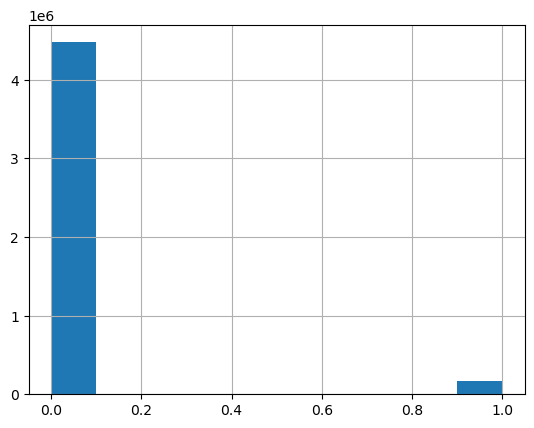

In [17]:
# Observons la répartition des erreurs de transaction
orders_data["isError"].hist()

## Features Engieering

In [18]:
orders_data.head()

,Unnamed: 0,TxHash,BlockHeight,TimeStamp,From,To,Value,isError
0,0,0xaca3850ba0080cf47b47f80e46da452f61bcbb5470d3...,5848095,1529873859,0x16f209b5332a1b4fa5bf19497ca40154c5db2f85,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.500000,0
1,1,0x95681862f9778e49caecf603dd911d6ed57f7799d89d...,5848181,1529875104,0xe7e07e44ee315b5f2d076340b2b7a5cc9a4ee57b,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.001020,0
2,2,0x716ae3961b50186a0bbc272cfcc4555662f7fe33550f...,5848716,1529883192,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0xe892875b87b94c44edf0e91ee9f49d0525fadd83,0.500390,0
3,3,0xf397197b800d6cc055a4db265b5e9df3dd2aa745c813...,5849038,1529887684,0x0681d8db095565fe8a346fa0277bffde9c0edbbf,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.817800,0
4,4,0x7f8086011a32f128dba57fe06fc5f4a181d2f5401e5a...,5849437,1529893144,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0xe892875b87b94c44edf0e91ee9f49d0525fadd83,0.817506,0


In [19]:
##################################### (1) Passons de la logique transaction à la logique Portefeuille ########################################
# 1. On s'assure que le TimeStamp est bien au format Date/Heure
orders_data = orders_data.copy()
orders_data['TimeStamp_dt'] = pd.to_datetime(orders_data['TimeStamp'], unit='s')

print("Agrégation des données par adresse")

# 2. On groupe par l'adresse de l'expéditeur ('From')
portefeuilles = orders_data.groupby('From').agg(
    nb_transactions=('TxHash', 'count'),
    total_eth_envoye=('Value', 'sum'),
    moyenne_eth_envoye=('Value', 'mean'),
    max_eth_envoye=('Value', 'max'),
    nb_erreurs=('isError', 'sum'),
    premier_tx=('TimeStamp_dt', 'min'),
    dernier_tx=('TimeStamp_dt', 'max')
).reset_index()

# 3. Création des variables comportementales (Durée de vie, Fréquence, Taux d'erreur)

# Durée de vie en heures
portefeuilles['duree_vie_heures'] = (portefeuilles['dernier_tx'] - portefeuilles['premier_tx']).dt.total_seconds() / 3600

# Fréquence de transactions par heure (on ajoute +1 pour éviter la division par zéro pour les wallets à 1 transaction)
portefeuilles['tx_par_heure'] = portefeuilles['nb_transactions'] / (portefeuilles['duree_vie_heures'] + 1)

# Taux d'échec des transactions (entre 0 et 1)
portefeuilles['taux_erreur'] = portefeuilles['nb_erreurs'] / portefeuilles['nb_transactions']

# 4. On nettoie les colonnes de dates qui ne servent plus à l'algorithme
portefeuilles_final = portefeuilles.drop(columns=['premier_tx', 'dernier_tx', 'nb_erreurs'])

print(f"✅ Terminé ! Nouveau jeu de données : {portefeuilles_final.shape[0]} portefeuilles uniques analysés.")
display(portefeuilles_final.head())

Agrégation des données par adresse
✅ Terminé ! Nouveau jeu de données : 734359 portefeuilles uniques analysés.


,From,nb_transactions,total_eth_envoye,moyenne_eth_envoye,max_eth_envoye,duree_vie_heures,tx_par_heure,taux_erreur
0,0x000000004fdd41501a42651743c55f7e41ec85e4,1,0.200000,0.200000,0.200000,0.000000,1.000000,0.0
1,0x00000000ad4eb06bc550dc45ce28888c0626839a,1,1.219414,1.219414,1.219414,0.000000,1.000000,0.0
2,0x0000000484f2217f1a64eb6d24b5cee446faeae5,2,0.002000,0.001000,0.001000,0.146389,1.744609,0.0
3,0x000000060d5f3af420ba8ce05d7b6151b62931e6,2,19.615000,9.807500,10.000000,2032.000000,0.000984,0.0
4,0x0000000b88aba43640254eed38c7343f35611bbe,1,0.050000,0.050000,0.050000,0.000000,1.000000,0.0


In [20]:
# Jetons un oeil aux Portefeuille
portefeuilles_final.describe()

,nb_transactions,total_eth_envoye,moyenne_eth_envoye,max_eth_envoye,duree_vie_heures,tx_par_heure,taux_erreur
count,734359.000000,7.343590e+05,734359.000000,7.343590e+05,734359.000000,734359.000000,734359.000000
mean,6.331891,5.281914e+02,52.928779,1.139045e+02,855.502546,0.772900,0.055317
std,395.281342,6.285747e+04,1451.547423,4.284160e+03,2564.002672,1.639191,0.198859
min,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000074,0.000000
25%,1.000000,1.785463e-01,0.131729,1.500000e-01,0.000000,0.042907,0.000000
50%,1.000000,1.280000e+00,1.000000,1.000000e+00,0.000000,1.000000,0.000000
75%,2.000000,7.994760e+00,4.096914,5.120526e+00,73.374444,1.000000,0.000000
max,256564.000000,2.763484e+07,541130.953016,1.943845e+06,36486.544722,977.501786,1.000000


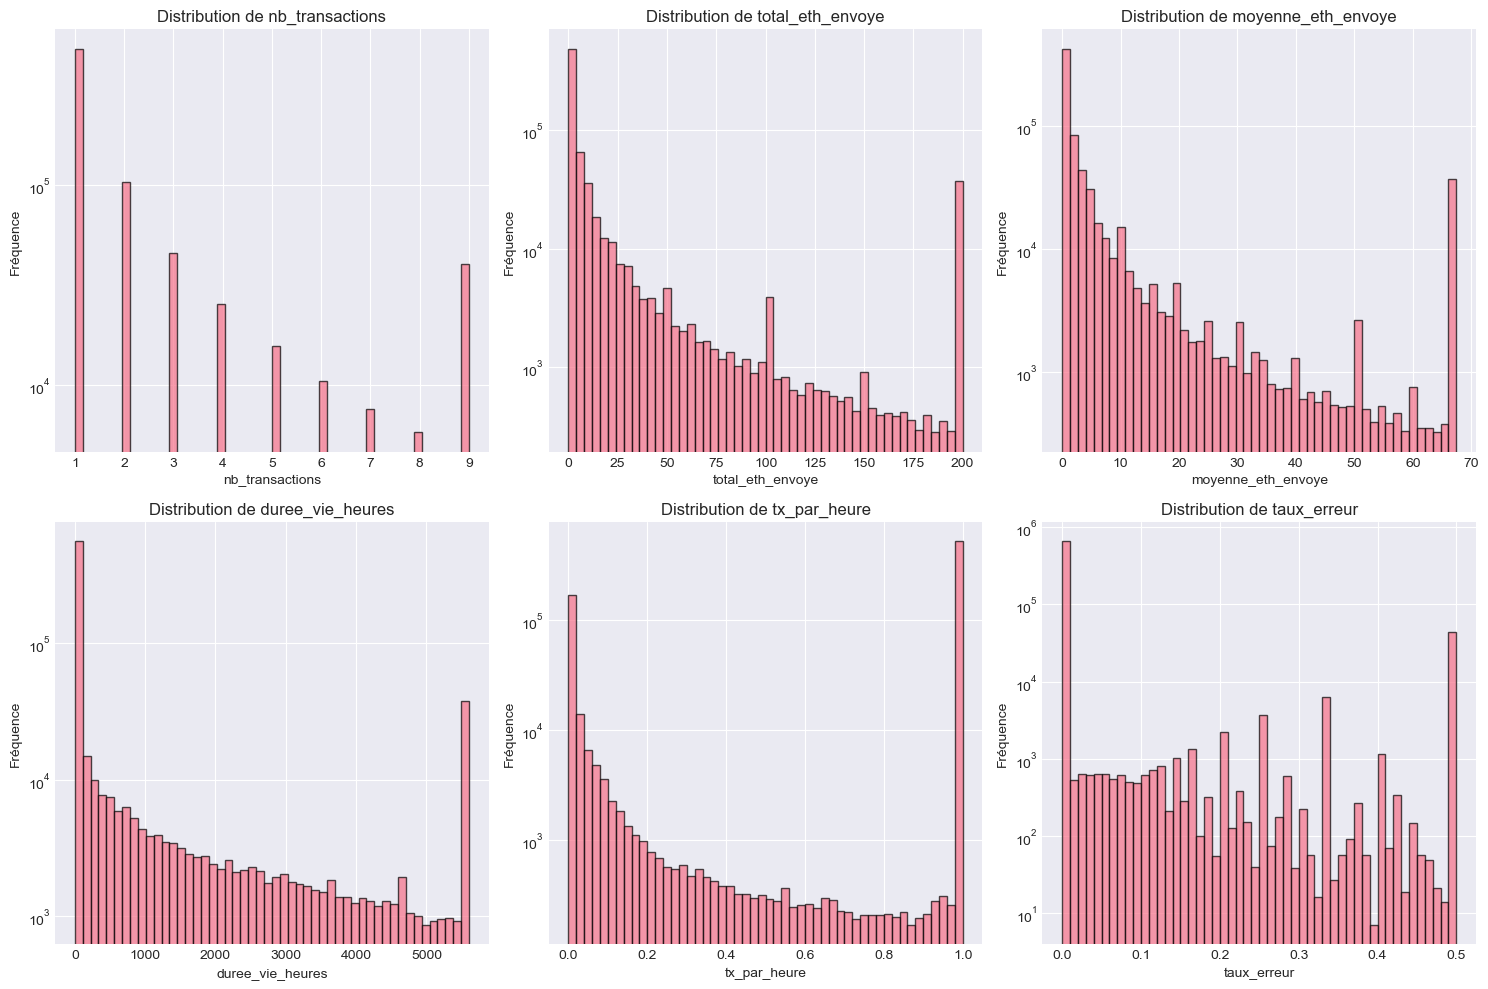

=== STATISTIQUES DES PERCENTILES ===

nb_transactions:
  50ème percentile : 1.00
  75ème percentile : 2.00
  90ème percentile : 5.00
  95ème percentile : 9.00
  99ème percentile : 49.00
  99.5ème percentile : 101.00
  99.9ème percentile : 490.00

total_eth_envoye:
  50ème percentile : 1.28
  75ème percentile : 7.99
  90ème percentile : 50.00
  95ème percentile : 199.99
  99ème percentile : 3000.00
  99.5ème percentile : 7000.00
  99.9ème percentile : 42012.09

moyenne_eth_envoye:
  50ème percentile : 1.00
  75ème percentile : 4.10
  90ème percentile : 20.00
  95ème percentile : 67.45
  99ème percentile : 855.03
  99.5ème percentile : 1798.99
  99.9ème percentile : 6500.00

duree_vie_heures:
  50ème percentile : 0.00
  75ème percentile : 73.37
  90ème percentile : 2643.49
  95ème percentile : 5604.47
  99ème percentile : 13766.26
  99.5ème percentile : 16404.66
  99.9ème percentile : 20832.26

tx_par_heure:
  50ème percentile : 1.00
  75ème percentile : 1.00
  90ème percentile : 1.00
  

In [21]:
# Configurer le style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Distribution des variables clés
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

variables_a_afficher = ['nb_transactions', 'total_eth_envoye', 'moyenne_eth_envoye', 
                        'duree_vie_heures', 'tx_par_heure', 'taux_erreur']

for idx, var in enumerate(variables_a_afficher):
    ax = axes[idx // 3, idx % 3]
    
    # En log scale pour mieux voir les extrêmes
    ax.hist(portefeuilles_final[var].clip(upper=portefeuilles_final[var].quantile(0.95)), 
            bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution de {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Fréquence')
    ax.set_yscale('log')  # Échelle log pour mieux voir

plt.tight_layout()
plt.show()

# 2. Statistiques des percentiles pour comprendre les seuils
print("=== STATISTIQUES DES PERCENTILES ===")
percentiles = [50, 75, 90, 95, 99, 99.5, 99.9]
for var in variables_a_afficher:
    print(f"\n{var}:")
    for p in percentiles:
        val = portefeuilles_final[var].quantile(p/100)
        print(f"  {p}ème percentile : {val:.2f}")

In [22]:
##################################### (2) Standardiser les données ########################################
from sklearn.preprocessing import StandardScaler, RobustScaler

# Sélection des features pour l'analyse (toutes sauf si certaines sont redondantes)
features = ['nb_transactions', 'total_eth_envoye', 'moyenne_eth_envoye', 
            'max_eth_envoye', 'duree_vie_heures', 'tx_par_heure', 'taux_erreur']

# Utiliser RobustScaler car nous avons des outliers (plus robuste que StandardScaler)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(portefeuilles_final[features])

# Convertir en DataFrame pour plus de lisibilité
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=portefeuilles_final.index)

print("✅ Données standardisées")
print(f"Shape: {X_scaled_df.shape}")
display(X_scaled_df.head())

✅ Données standardisées
Shape: (734359, 7)


,nb_transactions,total_eth_envoye,moyenne_eth_envoye,max_eth_envoye,duree_vie_heures,tx_par_heure,taux_erreur
0,0.0,-0.138174,-0.201756,-0.160949,0.000000,0.000000,0.0
1,0.0,-0.007751,0.055335,0.044143,0.000000,0.000000,0.0
2,1.0,-0.163506,-0.251943,-0.200985,0.001995,0.777990,0.0
3,1.0,2.345765,2.221208,1.810674,27.693566,-1.043803,0.0
4,0.0,-0.157365,-0.239585,-0.191127,0.000000,0.000000,0.0


## Modele Machine Learning non suppervisé

### Isolation Forest

In [23]:
from sklearn.ensemble import IsolationForest
import numpy as np

# 1. Instancier le modèle
iso_forest = IsolationForest(
    contamination=0.01,  # On suppose que 1% des portefeuilles sont suspects
    random_state=42,
    n_estimators=100
)

# 2. Entraîner et prédire
iso_forest.fit(X_scaled)
predictions = iso_forest.predict(X_scaled)  # -1 = anomalie, 1 = normal
anomaly_scores = iso_forest.decision_function(X_scaled)  # Plus le score est négatif, plus c'est anormal

# 3. Ajouter les résultats au dataframe
portefeuilles_final['is_anomaly_if'] = (predictions == -1).astype(int)
portefeuilles_final['anomaly_score_if'] = anomaly_scores

# 4. Compter les anomalies
nb_anomalies = portefeuilles_final['is_anomaly_if'].sum()
print(f"🔍 Isolation Forest - Anomalies détectées : {nb_anomalies} ({nb_anomalies/len(portefeuilles_final)*100:.2f}%)")

🔍 Isolation Forest - Anomalies détectées : 7341 (1.00%)


### Modèle Autoencoder

In [24]:
# Installer tensorflow si pas déjà fait
# !pip install tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer pour la reproductibilité
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU disponible: []


In [25]:
# 1. Sélection des features (les mêmes que pour Isolation Forest)
features = ['nb_transactions', 'total_eth_envoye', 'moyenne_eth_envoye', 
            'max_eth_envoye', 'duree_vie_heures', 'tx_par_heure', 'taux_erreur']

# 2. Normalisation (RobustScaler pour gérer les outliers)
scaler_ae = RobustScaler()
X_scaled_ae = scaler_ae.fit_transform(portefeuilles_final[features])

# 3. Split en train/validation (pas de test car non supervisé)
X_train_ae, X_val_ae = train_test_split(
    X_scaled_ae, 
    test_size=0.2, 
    random_state=42
)

print(f"✅ Données préparées")
print(f"  - Features: {len(features)}")
print(f"  - Train: {X_train_ae.shape[0]} samples")
print(f"  - Validation: {X_val_ae.shape[0]} samples")

✅ Données préparées
  - Features: 7
  - Train: 587487 samples
  - Validation: 146872 samples


In [26]:
# Définir l'architecture
input_dim = X_train_ae.shape[1]
encoding_dim = 3  # Dimension de l'espace latent

# Encoder
encoder_input = layers.Input(shape=(input_dim,))
x = layers.Dense(32, activation='relu')(encoder_input)
x = layers.Dropout(0.2)(x)  # Dropout pour éviter l'overfitting
x = layers.Dense(16, activation='relu')(x)
x = layers.Dropout(0.2)(x)
encoder_output = layers.Dense(encoding_dim, activation='relu', name='bottleneck')(x)

# Decoder
decoder_input = encoder_output
x = layers.Dense(16, activation='relu')(decoder_input)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.2)(x)
decoder_output = layers.Dense(input_dim, activation='linear')(x)

# Autoencoder complet
autoencoder = keras.Model(encoder_input, decoder_output, name='autoencoder')

# Encodeur séparé (pour extraire les features latentes)
encoder = keras.Model(encoder_input, encoder_output, name='encoder')

# Compiler avec un learning rate adaptatif
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

# Afficher l'architecture
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 3)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,674 (6.54 KB)

 Trainable params: 1,674 (6.54 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Callbacks pour améliorer l'entraînement
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Entraînement
history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=100,
    batch_size=256,  # Batch size adapté pour 170k samples
    validation_data=(X_val_ae, X_val_ae),
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
    shuffle=True
)

Epoch 1/100
2295/2295 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 2215315.5000 - val_loss: 407355.6250 - learning_rate: 0.0010
Epoch 2/100
2295/2295 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1363956.3750 - val_loss: 619698.2500 - learning_rate: 0.0010
Epoch 3/100
2295/2295 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 3999706.2500 - val_loss: 421047.5000 - learning_rate: 0.0010
Epoch 4/100
2295/2295 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 3766643.2500 - val_loss: 321983.8438 - learning_rate: 0.0010
Epoch 5/100
2295/2295 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 3428913.0000 - val_loss: 1159846.8750 - learning_rate: 0.0010
Epoch 6/100
2295/2295 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5017676.0000 - val_loss: 720673.3125 - learning_rate: 0.0010
Epoch 7/100
2295/2295 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 3626918.2500 - val_loss: 106407.5000 - learning_rate: 0.0010
Epoch 8/100
2295/2295 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3588762.0000 - val_loss: 766871.4375 - learning_rate: 0.0010
Epoch 9

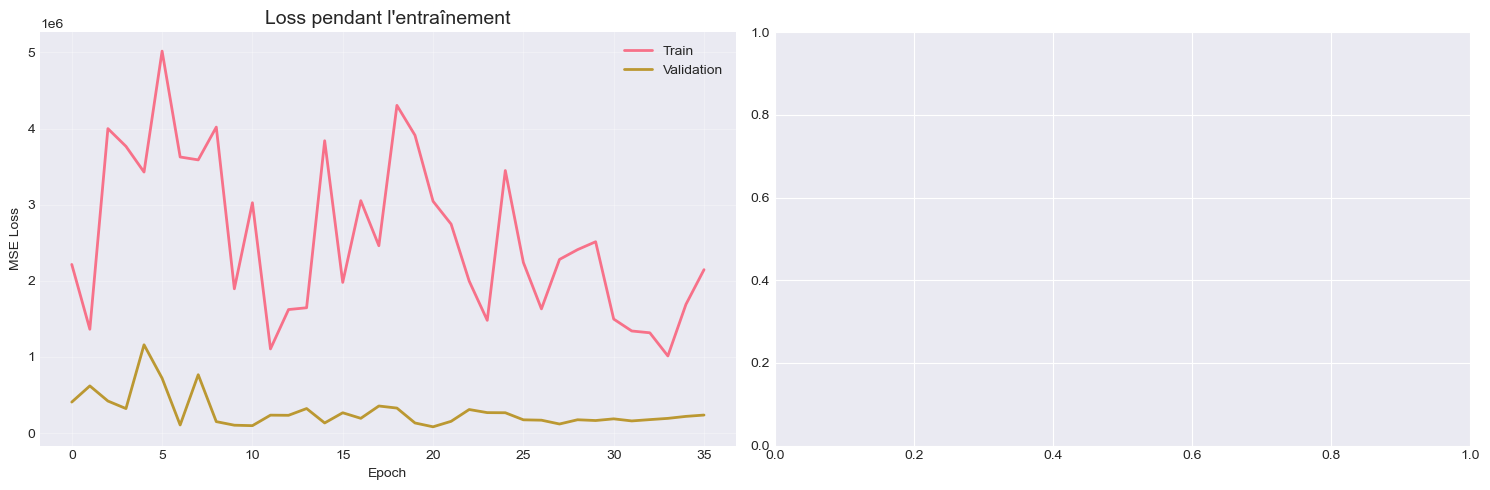

✅ Entraînement terminé
  - Meilleure loss validation: 82487.171875
  - Epochs totales: 36


In [28]:
# Plot de la loss
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0].set_title('Loss pendant l\'entraînement', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learning rate
if 'lr' in history.history:
    axes[1].plot(history.history['lr'], linewidth=2)
    axes[1].set_title('Learning Rate', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('LR')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ Entraînement terminé")
print(f"  - Meilleure loss validation: {min(history.history['val_loss']):.6f}")
print(f"  - Epochs totales: {len(history.history['loss'])}")

In [29]:
# Prédire sur tous les portefeuilles
reconstructions = autoencoder.predict(X_scaled_ae, batch_size=256, verbose=0)

# Calculer l'erreur MSE pour chaque portefeuille
mse = np.mean(np.square(X_scaled_ae - reconstructions), axis=1)

# Ajouter au dataframe
portefeuilles_final['reconstruction_error'] = mse

# Statistiques de l'erreur
print("=== STATISTIQUES DE L'ERREUR DE RECONSTRUCTION ===\n")
print(f"Moyenne: {mse.mean():.6f}")
print(f"Médiane: {np.median(mse):.6f}")
print(f"Std: {mse.std():.6f}")
print(f"Max: {mse.max():.6f}")
print(f"\nPercentiles:")
for p in [50, 75, 90, 95, 99, 99.5, 99.9]:
    print(f"  {p}ème: {np.percentile(mse, p):.6f}")

=== STATISTIQUES DE L'ERREUR DE RECONSTRUCTION ===

Moyenne: 137633.109519
Médiane: 29.364238
Std: 31478758.592893
Max: 13792362701.758991

Percentiles:
  50ème: 29.364238
  75ème: 29.993256
  90ème: 351.360419
  95ème: 1751.116979
  99ème: 23180.036132
  99.5ème: 102392.604766
  99.9ème: 1433761.944970


In [30]:
# Méthode 1: Percentile (classique)
percentile_threshold = 95  # À ajuster selon tes besoins
threshold_percentile = np.percentile(mse, percentile_threshold)

# Méthode 2: Moyenne + 3 écarts-types (pour distribution normale)
threshold_sigma = mse.mean() + 3 * mse.std()

# Méthode 3: IQR (robuste aux outliers)
Q1 = np.percentile(mse, 25)
Q3 = np.percentile(mse, 75)
IQR = Q3 - Q1
threshold_iqr = Q3 + 1.5 * IQR

print("=== SEUILS D'ANOMALIE POTENTIELS ===\n")
print(f"📊 Méthode Percentile (95%): {threshold_percentile:.6f}")
print(f"📊 Méthode Sigma (μ+3σ): {threshold_sigma:.6f}")
print(f"📊 Méthode IQR (Q3+1.5*IQR): {threshold_iqr:.6f}")

# Choisir le seuil (je recommande le percentile 95%)
threshold = threshold_percentile
portefeuilles_final['is_anomaly_ae'] = (mse > threshold).astype(int)

print(f"\n✅ Anomalies détectées: {portefeuilles_final['is_anomaly_ae'].sum()} "
      f"({portefeuilles_final['is_anomaly_ae'].sum()/len(portefeuilles_final)*100:.2f}%)")

=== SEUILS D'ANOMALIE POTENTIELS ===

📊 Méthode Percentile (95%): 1751.116979
📊 Méthode Sigma (μ+3σ): 94573908.888198
📊 Méthode IQR (Q3+1.5*IQR): 35.322972

✅ Anomalies détectées: 36718 (5.00%)


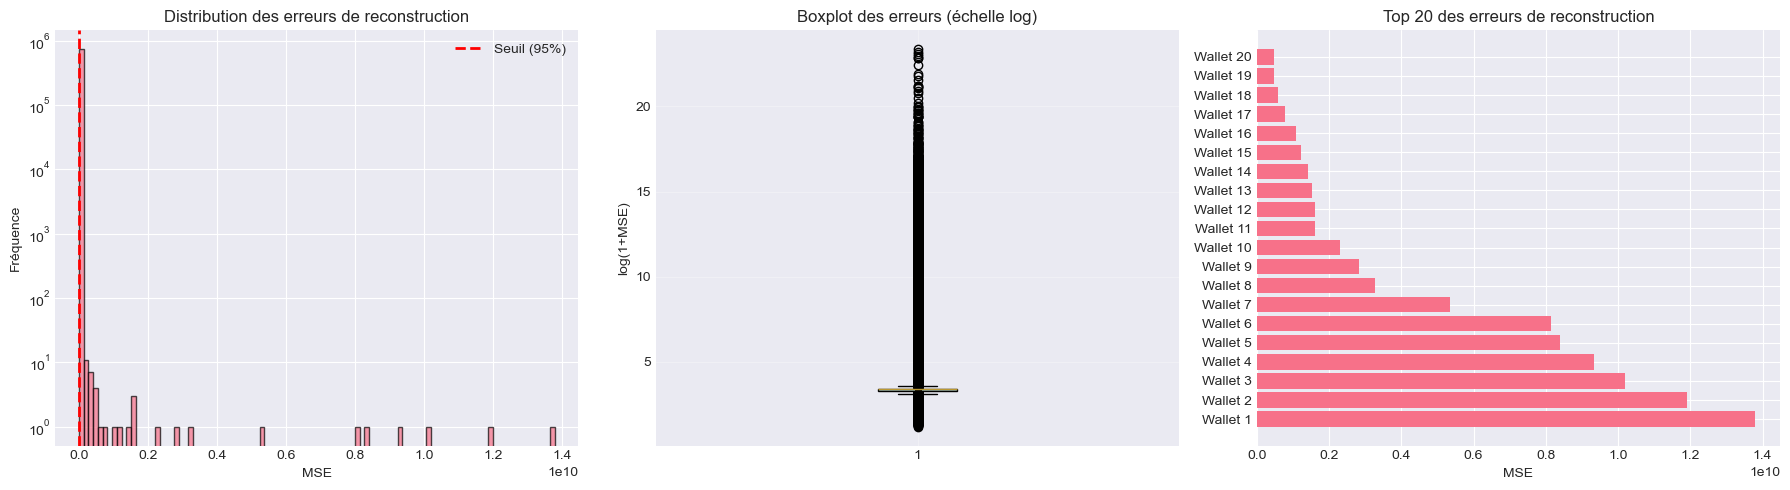

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution des erreurs
axes[0].hist(mse, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Seuil ({percentile_threshold}%)')
axes[0].set_title('Distribution des erreurs de reconstruction')
axes[0].set_xlabel('MSE')
axes[0].set_ylabel('Fréquence')
axes[0].set_yscale('log')
axes[0].legend()

# 2. Boxplot (log scale pour mieux voir)
mse_log = np.log1p(mse)
bp = axes[1].boxplot(mse_log, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[1].set_title('Boxplot des erreurs (échelle log)')
axes[1].set_ylabel('log(1+MSE)')
axes[1].grid(True, alpha=0.3)

# 3. Erreur par type de portefeuille (top 20)
top_anomalies_ae = portefeuilles_final.nlargest(20, 'reconstruction_error')
axes[2].barh(range(len(top_anomalies_ae)), top_anomalies_ae['reconstruction_error'].values)
axes[2].set_title('Top 20 des erreurs de reconstruction')
axes[2].set_xlabel('MSE')
axes[2].set_yticks(range(len(top_anomalies_ae)))
axes[2].set_yticklabels([f"Wallet {i+1}" for i in range(len(top_anomalies_ae))])

plt.tight_layout()
plt.show()

### Comparaison des modèles

In [32]:
# Vérifier les colonnes existantes
print("=== COLONNES DISPONIBLES DANS LE DATAFRAME ===\n")
for col in portefeuilles_final.columns:
    print(f"  - {col}")

=== COLONNES DISPONIBLES DANS LE DATAFRAME ===

  - From
  - nb_transactions
  - total_eth_envoye
  - moyenne_eth_envoye
  - max_eth_envoye
  - duree_vie_heures
  - tx_par_heure
  - taux_erreur
  - is_anomaly_if
  - anomaly_score_if
  - reconstruction_error
  - is_anomaly_ae


In [33]:
# 1. Compter les anomalies de chaque modèle
n_if = portefeuilles_final['is_anomaly_if'].sum()
n_ae = portefeuilles_final['is_anomaly_ae'].sum()
n_common = ((portefeuilles_final['is_anomaly_if'] == 1) & 
            (portefeuilles_final['is_anomaly_ae'] == 1)).sum()

print("="*60)
print("📊 RÉSULTATS DES DEUX MODÈLES")
print("="*60)
print(f"Isolation Forest   : {n_if:>6,} anomalies ({n_if/len(portefeuilles_final)*100:>5.2f}%)")
print(f"Autoencoder         : {n_ae:>6,} anomalies ({n_ae/len(portefeuilles_final)*100:>5.2f}%)")
print(f"Anomalies communes  : {n_common:>6,} ({n_common/len(portefeuilles_final)*100:>5.2f}%)")

# 2. Accord entre les modèles
kappa = cohen_kappa_score(portefeuilles_final['is_anomaly_if'], 
                          portefeuilles_final['is_anomaly_ae'])
print(f"\n📈 Coefficient Kappa (accord entre modèles) : {kappa:.3f}")
if kappa > 0.7:
    print("   → Accord excellent")
elif kappa > 0.5:
    print("   → Accord modéré")
else:
    print("   → Accord faible (les modèles capturent des anomalies différentes)")

# 3. Consensus (anomalie détectée par AU MOINS un modèle)
portefeuilles_final['consensus_anomaly'] = (
    (portefeuilles_final['is_anomaly_if'] == 1) | 
    (portefeuilles_final['is_anomaly_ae'] == 1)
).astype(int)

n_consensus = portefeuilles_final['consensus_anomaly'].sum()
print(f"\n🎯 Consensus (au moins 1 modèle) : {n_consensus:>6,} anomalies ({n_consensus/len(portefeuilles_final)*100:>5.2f}%)")

📊 RÉSULTATS DES DEUX MODÈLES
Isolation Forest   :  7,341 anomalies ( 1.00%)
Autoencoder         : 36,718 anomalies ( 5.00%)
Anomalies communes  :  7,216 ( 0.98%)

📈 Coefficient Kappa (accord entre modèles) : 0.316
   → Accord faible (les modèles capturent des anomalies différentes)

🎯 Consensus (au moins 1 modèle) : 36,843 anomalies ( 5.02%)


In [34]:
# 1. Créer une colonne de niveau de risque (3 niveaux)
conditions = [
    (portefeuilles_final['is_anomaly_if'] == 1) & (portefeuilles_final['is_anomaly_ae'] == 1),  # Les deux
    (portefeuilles_final['is_anomaly_if'] == 1) | (portefeuilles_final['is_anomaly_ae'] == 1),  # Un seul
]
choices = ['Risque ÉLEVÉ', 'Risque MODÉRÉ']
portefeuilles_final['niveau_risque'] = np.select(conditions, choices, default='Normal')

print("=== NIVEAUX DE RISQUE ===\n")
print(portefeuilles_final['niveau_risque'].value_counts())
print("\n" + "-"*50)

# 2. Top 20 des portefeuilles les plus suspects (score IF + erreur AE)
portefeuilles_final['score_risque_composite'] = (
    # Normaliser les scores entre 0 et 1
    (portefeuilles_final['anomaly_score_if'].max() - portefeuilles_final['anomaly_score_if']) / 
    (portefeuilles_final['anomaly_score_if'].max() - portefeuilles_final['anomaly_score_if'].min()) +
    (portefeuilles_final['reconstruction_error'] - portefeuilles_final['reconstruction_error'].min()) /
    (portefeuilles_final['reconstruction_error'].max() - portefeuilles_final['reconstruction_error'].min())
)

top_suspects = portefeuilles_final.nlargest(20, 'score_risque_composite')

print("\n🔴 TOP 20 DES PORTEFEUILLES LES PLUS SUSPECTS 🔴\n")
display(top_suspects[['From', 'nb_transactions', 'total_eth_envoye', 
                       'tx_par_heure', 'taux_erreur', 'niveau_risque',
                       'anomaly_score_if', 'reconstruction_error']])

=== NIVEAUX DE RISQUE ===

niveau_risque
Normal           697516
Risque MODÉRÉ     29627
Risque ÉLEVÉ       7216
Name: count, dtype: int64

--------------------------------------------------

🔴 TOP 20 DES PORTEFEUILLES LES PLUS SUSPECTS 🔴



,From,nb_transactions,total_eth_envoye,tx_par_heure,taux_erreur,niveau_risque,anomaly_score_if,reconstruction_error
65025,0x1151314c646ce4e0efd76d1af4760ae66a9fe30f,13012,2.512599e+07,1.122158,0.000922,Risque ÉLEVÉ,-0.131684,1.379236e+10
238587,0x4e9ce36e442e55ecd9025b9a6e0d88485d628a67,6,3.246786e+06,0.001080,0.000000,Risque ÉLEVÉ,-0.094686,1.191768e+10
587808,0xcafb10ee663f465f9d10588ac44ed20ed608c11e,823,2.351327e+07,0.062539,0.006075,Risque ÉLEVÉ,-0.136221,1.018079e+10
674453,0xea674fdde714fd979de3edf0f56aa9716b898ec8,256564,1.024114e+05,8.218421,0.000133,Risque ÉLEVÉ,-0.115263,9.325413e+09
159429,0x32be343b94f860124dc4fee278fdcbd38c102d88,24485,2.763484e+07,0.711487,0.002859,Risque ÉLEVÉ,-0.140782,8.381014e+09
533744,0xb794f5ea0ba39494ce839613fffba74279579268,206,2.209510e+07,0.009240,0.000000,Risque ÉLEVÉ,-0.136790,8.132511e+09
250246,0x52bc44d5378309ee2abf1539bf71de1b7d7be3b5,194379,9.159430e+04,5.332299,0.000000,Risque ÉLEVÉ,-0.122685,5.349333e+09
730274,0xfe9e8709d3215310075d67e3ed32a380ccf451c8,4,1.844825e+06,0.004292,0.000000,Risque ÉLEVÉ,-0.090739,3.280739e+09
206739,0x4366ddc115d8cf213c564da36e64c8ebaa30cdbd,1,4.636218e+05,1.000000,0.000000,Risque ÉLEVÉ,-0.091427,2.833174e+09
9272,0x008024771614f4290696b63ba3dd3a1ceb34d4d9,2900,7.243293e+06,0.205213,0.021379,Risque ÉLEVÉ,-0.135084,1.526485e+09


In [35]:
# 1. Séparer les différentes catégories
normaux = portefeuilles_final[portefeuilles_final['niveau_risque'] == 'Normal']
risque_modere = portefeuilles_final[portefeuilles_final['niveau_risque'] == 'Risque MODÉRÉ']
risque_eleve = portefeuilles_final[portefeuilles_final['niveau_risque'] == 'Risque ÉLEVÉ']

features = ['nb_transactions', 'total_eth_envoye', 'moyenne_eth_envoye', 
            'max_eth_envoye', 'duree_vie_heures', 'tx_par_heure', 'taux_erreur']

print("=== PROFIL DES DIFFÉRENTS NIVEAUX DE RISQUE ===\n")

for risk_level, df_risk in [('Normal', normaux), ('Modéré', risque_modere), ('Élevé', risque_eleve)]:
    print(f"\n📊 {risk_level} (n={len(df_risk):,})")
    print("-"*40)
    for f in features:
        mean_val = df_risk[f].mean()
        median_val = df_risk[f].median()
        print(f"  {f:25s}: moyenne={mean_val:10.2f} | médiane={median_val:10.2f}")

=== PROFIL DES DIFFÉRENTS NIVEAUX DE RISQUE ===


📊 Normal (n=697,516)
----------------------------------------
  nb_transactions          : moyenne=      2.20 | médiane=      1.00
  total_eth_envoye         : moyenne=     18.83 | médiane=      1.07
  moyenne_eth_envoye       : moyenne=      8.01 | médiane=      0.99
  max_eth_envoye           : moyenne=     11.35 | médiane=      1.00
  duree_vie_heures         : moyenne=    478.96 | médiane=      0.00
  tx_par_heure             : moyenne=      0.79 | médiane=      1.00
  taux_erreur              : moyenne=      0.06 | médiane=      0.00

📊 Modéré (n=29,627)
----------------------------------------
  nb_transactions          : moyenne=     32.64 | médiane=      7.00
  total_eth_envoye         : moyenne=    681.11 | médiane=    219.05
  moyenne_eth_envoye       : moyenne=    261.04 | médiane=      9.50
  max_eth_envoye           : moyenne=    396.62 | médiane=     50.00
  duree_vie_heures         : moyenne=   8301.55 | médiane=   9605.8

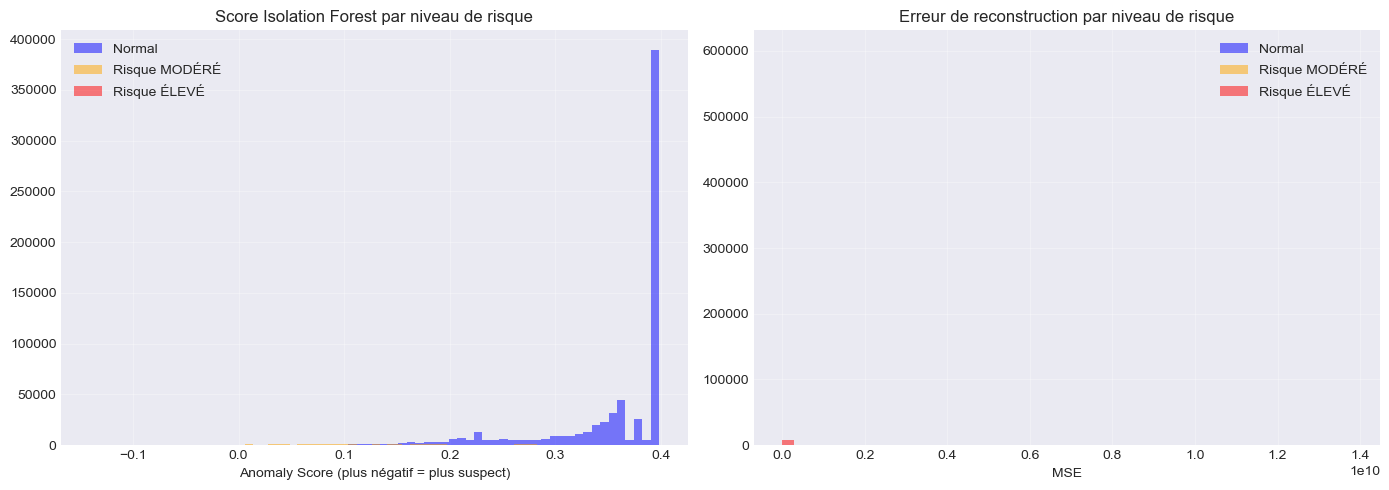

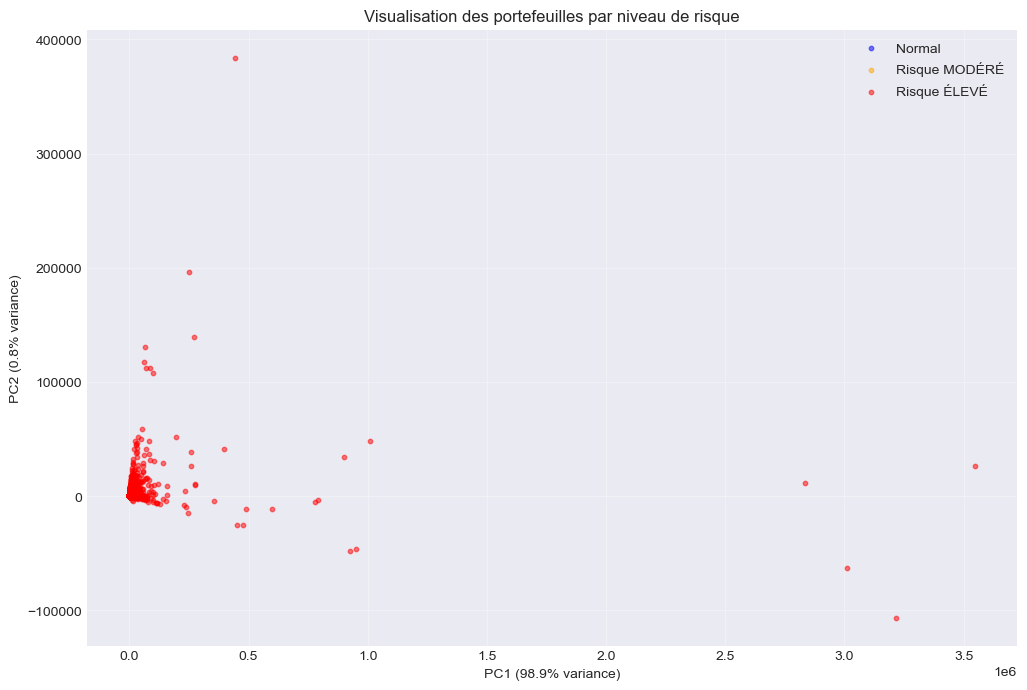

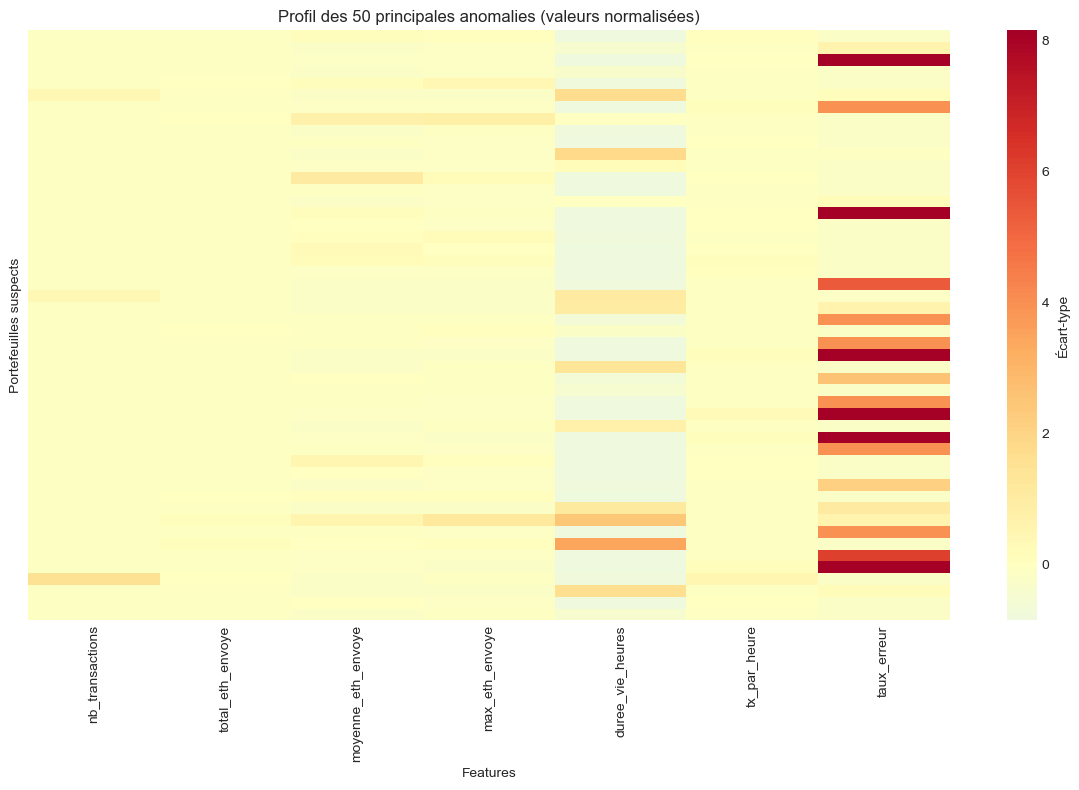

In [36]:
# 1. Distribution des scores par niveau de risque
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score Isolation Forest
colors = {'Normal': 'blue', 'Risque MODÉRÉ': 'orange', 'Risque ÉLEVÉ': 'red'}
for risk, color in colors.items():
    subset = portefeuilles_final[portefeuilles_final['niveau_risque'] == risk]
    axes[0].hist(subset['anomaly_score_if'], bins=50, alpha=0.5, label=risk, color=color)
axes[0].set_title('Score Isolation Forest par niveau de risque')
axes[0].set_xlabel('Anomaly Score (plus négatif = plus suspect)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Erreur de reconstruction
for risk, color in colors.items():
    subset = portefeuilles_final[portefeuilles_final['niveau_risque'] == risk]
    axes[1].hist(subset['reconstruction_error'], bins=50, alpha=0.5, label=risk, color=color)
axes[1].set_title('Erreur de reconstruction par niveau de risque')
axes[1].set_xlabel('MSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Visualisation 2D (PCA) avec les niveaux de risque
from sklearn.decomposition import PCA

scaler_viz = RobustScaler()
X_viz = scaler_viz.fit_transform(portefeuilles_final[features])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_viz)

plt.figure(figsize=(12, 8))

for risk, color in colors.items():
    mask = portefeuilles_final['niveau_risque'] == risk
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=color, label=risk, alpha=0.5, s=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Visualisation des portefeuilles par niveau de risque')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Heatmap des features pour les anomalies
plt.figure(figsize=(12, 8))

# Sélectionner les anomalies de haut risque
high_risk_data = portefeuilles_final[portefeuilles_final['niveau_risque'] == 'Risque ÉLEVÉ'][features]

# Normaliser pour la heatmap
from sklearn.preprocessing import StandardScaler
scaler_hm = StandardScaler()
high_risk_scaled = scaler_hm.fit_transform(high_risk_data)

sns.heatmap(high_risk_scaled[:50],  # Top 50 anomalies
            xticklabels=features, 
            yticklabels=False,
            cmap='RdYlBu_r', 
            center=0,
            cbar_kws={'label': 'Écart-type'})
plt.title('Profil des 50 principales anomalies (valeurs normalisées)')
plt.xlabel('Features')
plt.ylabel('Portefeuilles suspects')
plt.tight_layout()
plt.show()

In [37]:
# 1. Sauvegarder les résultats
portefeuilles_final.to_csv('portefeuilles_avec_risques.csv', index=False)

# 2. Sauvegarder les modèles pour l'interface
import joblib

# Isolation Forest
if 'iso_forest' in locals():
    joblib.dump(iso_forest, 'iso_forest_model.pkl')
else:
    print("⚠️  L'objet Isolation Forest n'est pas en mémoire, mais les prédictions sont sauvegardées")

# Sauvegarder le scaler
scaler_viz = RobustScaler()
scaler_viz.fit(portefeuilles_final[features])
joblib.dump(scaler_viz, 'scaler_features.pkl')

# Sauvegarder les features names
joblib.dump(features, 'features_names.pkl')

print("\n✅ Tous les fichiers exportés avec succès !")
print("   - portefeuilles_avec_risques.csv")
print("   - scaler_features.pkl")
print("   - features_names.pkl")


✅ Tous les fichiers exportés avec succès !
   - portefeuilles_avec_risques.csv
   - scaler_features.pkl
   - features_names.pkl


In [38]:
import joblib
import numpy as np

# Supposons que 'reconstruction_error' contient les erreurs de tout le dataset
threshold = np.percentile(mse, 95)

# On sauvegarde ce seuil avec joblib
joblib.dump(threshold, 'autoencoder_threshold.pkl')

['autoencoder_threshold.pkl']

In [39]:
# Sauvegarder au format natif
autoencoder.save('autoencoder_model.keras')
print("✅ Modèle sauvegardé avec succès")

✅ Modèle sauvegardé avec succès


In [40]:
# Test de chargement
test_load = tf.keras.models.load_model('autoencoder_model.keras')
print("✅ Modèle chargé avec succès")

✅ Modèle chargé avec succès
